<a href="https://colab.research.google.com/github/mithra-malicious/carisurg_portfolio/blob/main/Tutorial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Matplotlib successfully loaded and ready")

Matplotlib successfully loaded and ready


In [3]:
FILE_PATH = '/content/drive/MyDrive/Copy of EmergencyTriageDataset_Reduced_Dirty.csv'

if not os.path.exists(FILE_PATH):
  print(f"Error: Place the dataset in: {os.getcwd()}")
else:
  df = pd.read_csv(FILE_PATH)

  gender_map = {'male': 1, '1': 1, '1.0': 1, 'female': 0, '0': 0, '0.0': 0}
  df['Gender'] = df['Gender'].astype(str).str.lower().str.strip().map(gender_map)
  df['Gender'] = df['Gender'].fillna(df['Gender'].median())

  clinical_bounds = {
        'GCS': {'min': 3.0, 'max': 15.0}, 'SBP': {'min': 60.0, 'max': 250.0},
        'DBP': {'min': 30.0, 'max': 150.0}, 'MAP': {'min': 40.0, 'max': 180.0},
        'pulse': {'min': 30.0, 'max': 220.0}, 'Temp': {'min': 34.0, 'max': 43.0},
        'RR': {'min': 8.0, 'max': 60.0}, 'Fio2': {'min': 21.0, 'max': 100.0}
  }
  for col, bounds in clinical_bounds.items():
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.loc[(df[col] < bounds['min']) | (df[col] > bounds['max']), col] = np.nan
        df[col] = df[col].fillna(df[col].median())
  print("Data pipeline executed: 1,000+ patient records perfectly cleaned and ready for plotting")

Data pipeline executed: 1,000+ patient records perfectly cleaned and ready for plotting


Saved plot


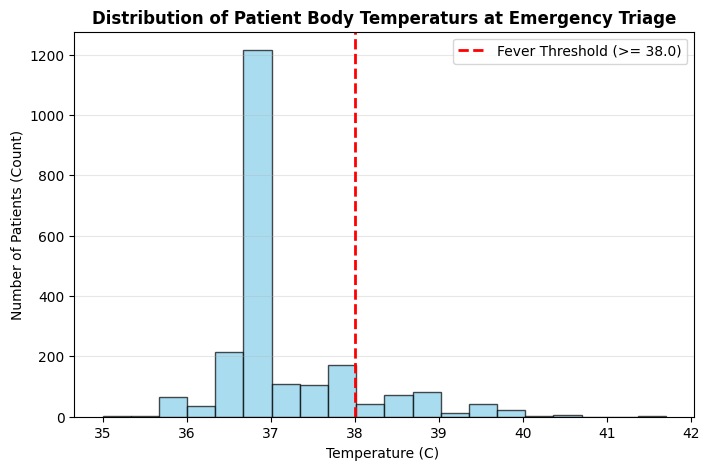

In [4]:
plt.figure(figsize=(8,5))

plt.hist(df['Temp'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(x=38.0, color='red', linestyle='--', linewidth=2, label='Fever Threshold (>= 38.0)')

plt.title('Distribution of Patient Body Temperaturs at Emergency Triage', fontsize=12, fontweight='bold')
plt.xlabel('Temperature (C) ', fontsize=10)
plt.ylabel('Number of Patients (Count)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(axis ='y', alpha = 0.3)

plt.savefig('clinical_temp_histogram.png', dpi=150, bbox_inches='tight')
print("Saved plot")
plt.show()


Saved plot as 'bp_relationship_scatter.png'


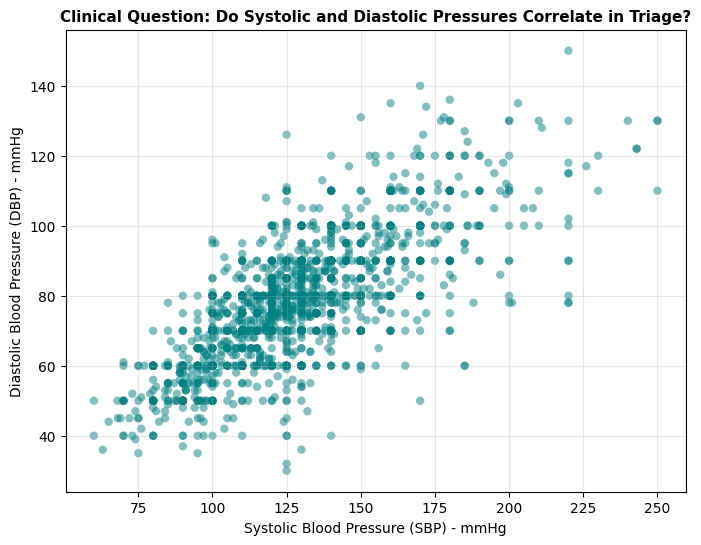

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(df['SBP'], df['DBP'], color='teal', alpha=0.5, edgecolor='none')
plt.title('Clinical Question: Do Systolic and Diastolic Pressures Correlate in Triage?', fontsize=11, fontweight='bold')
plt.xlabel('Systolic Blood Pressure (SBP) - mmHg', fontsize=10)
plt.ylabel('Diastolic Blood Pressure (DBP) - mmHg', fontsize=10)
plt.grid('true', alpha=0.3)

plt.savefig('bp_relationship_scatter.png', dpi=150, bbox_inches='tight')
print("Saved plot as 'bp_relationship_scatter.png'")
plt.show()

 Saved plot


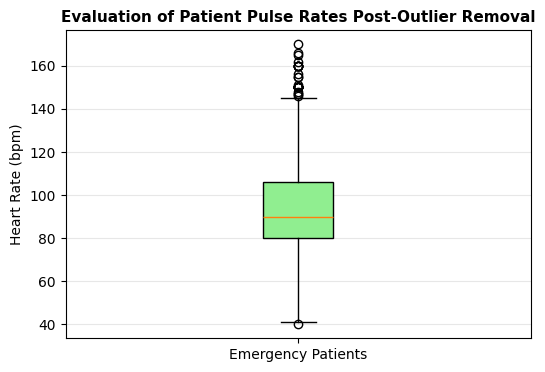

In [6]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['pulse'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))

plt.title('Evaluation of Patient Pulse Rates Post-Outlier Removal', fontsize=11, fontweight='bold')
plt.ylabel('Heart Rate (bpm)', fontsize=10)
plt.xticks([1], ['Emergency Patients'])
plt.grid(axis='y', alpha=0.3)

plt.savefig('pulse_box_plot.png', dpi=150, bbox_inches='tight')
print(" Saved plot")
plt.show()